# Random Forest Performance Under Label Noise

This experiment investigates how incorrect target labels affect the performance of a Random Forest classifier.

The Titanic dataset is used to introduce different levels of label noise and evaluate how the model responds to increasingly unreliable target labels.

## Introduction

Previous experiments investigated the effect of label noise on Logistic Regression and Decision Tree performance using the Titanic dataset.

In this experiment, the same label noise procedure will be applied to a Random Forest classifier.

Different levels of label noise will be introduced into the target variable, while the features and experimental conditions remain unchanged.

The objective is to determine how sensitive the Random Forest model is to incorrect target labels and to provide results for comparison with the other machine learning models.

## Import Libraries

The following libraries are required for data processing, model training, evaluation, and visualization.

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix)

import matplotlib.pyplot as plt

## Load Dataset

The Titanic dataset is loaded into a pandas DataFrame.

The same dataset and preprocessing approach used in the previous experiments are used to ensure that the results can be compared consistently.

In [2]:
df = pd.read_csv("Titanic-Dataset.csv")

## Data Preparation

Before introducing label noise, the dataset is preprocessed using the same procedure as in the previous experiments.

Missing values are handled, categorical variables are converted into numerical values using one-hot encoding, and unnecessary columns are removed.

Keeping the preprocessing procedure consistent allows the effect of label noise to be isolated.

In [3]:
df["Age"] = df["Age"].fillna(df["Age"].median())

df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

df = pd.get_dummies(df, columns=["Sex", "Embarked"],drop_first=True)

df = df.drop( columns=["PassengerId", "Name", "Ticket", "Cabin"])

## Create a Clean Dataset

A copy of the preprocessed dataset is created.

The clean dataset is kept unchanged so that different levels of label noise can be generated from the same original data.

In [4]:
clean_df = df.copy()

## Label Noise Injection

A function is used to introduce label noise into the target variable.

A specified fraction of the Survived labels is randomly selected and flipped. A value of 1 becomes 0, while a value of 0 becomes 1.

This simulates incorrectly recorded target labels in a real-world dataset.

In [5]:
def add_noise(dataframe, noise_fraction, random_state=42):

    noisy_df = dataframe.copy()

    noisy_indices = noisy_df.sample(frac=noise_fraction,random_state=random_state ).index

    noisy_df.loc[noisy_indices, "Survived"] = 1 - noisy_df.loc[ noisy_indices,"Survived"]

    return noisy_df

## Create Noisy Versions of the Dataset

Four versions of the dataset are created containing 0%, 10%, 20%, and 30% label noise.

The 0% noise dataset is used as the baseline, while the other datasets contain increasingly unreliable target labels.

In [6]:
noisy_10 = add_noise(clean_df, 0.10)
noisy_20 = add_noise(clean_df, 0.20)
noisy_30 = add_noise(clean_df, 0.30)

datasets = {"0% noise": clean_df,"10% noise": noisy_10,"20% noise": noisy_20, "30% noise": noisy_30}

## Train and Evaluate Random Forest

A separate Random Forest classifier is trained on each version of the dataset.

The same train-test split and random state are used for every experiment to ensure a fair comparison between noise levels.

Accuracy, Precision, Recall, F1-score, and confusion matrix values are calculated for each level of label noise.

In [7]:
results = {}

for name, data in datasets.items():

    X = data.drop(columns=["Survived"])
    y = data["Survived"]

    X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2,random_state=42)

    model = RandomForestClassifier( n_estimators=100,random_state=42)

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    tn, fp, fn, tp = confusion_matrix(y_test,y_pred).ravel()

    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "True Negative": tn,
        "False Positive": fp,
        "False Negative": fn,
        "True Positive": tp}

## Results

The results from each label noise level are combined into a single table.

This table allows the effect of increasing label noise on Random Forest performance to be evaluated using several classification metrics.

In [8]:
comparison = pd.DataFrame(results).T

comparison = comparison.round(3)

comparison

,Accuracy,Precision,Recall,F1-score,True Negative,False Positive,False Negative,True Positive
0% noise,0.821,0.800,0.757,0.778,91.0,14.0,18.0,56.0
10% noise,0.480,0.486,0.374,0.422,52.0,36.0,57.0,34.0
20% noise,0.184,0.214,0.142,0.170,18.0,55.0,91.0,15.0
30% noise,0.263,0.315,0.219,0.258,24.0,50.0,82.0,23.0


## Accuracy Comparison

The following graph shows how Random Forest Accuracy changes as the level of label noise increases.

Accuracy represents the proportion of correctly classified observations.

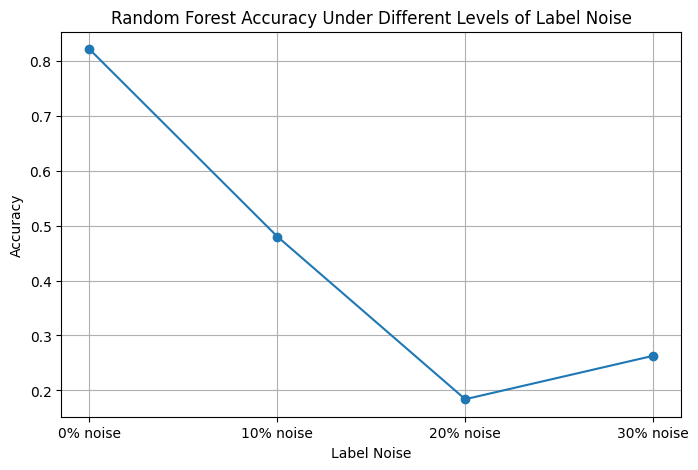

In [9]:
plt.figure(figsize=(8, 5))

plt.plot(comparison.index,comparison["Accuracy"],marker="o")

plt.xlabel("Label Noise")
plt.ylabel("Accuracy")
plt.title("Random Forest Accuracy Under Different Levels of Label Noise")

plt.grid(True)

plt.savefig("random_forest_label_noise_accuracy.png")

plt.show()

## F1-score Comparison

The following graph shows how the F1-score of the Random Forest model changes as the level of label noise increases.

The F1-score provides a balanced evaluation of Precision and Recall and is useful for evaluating changes in classification performance.

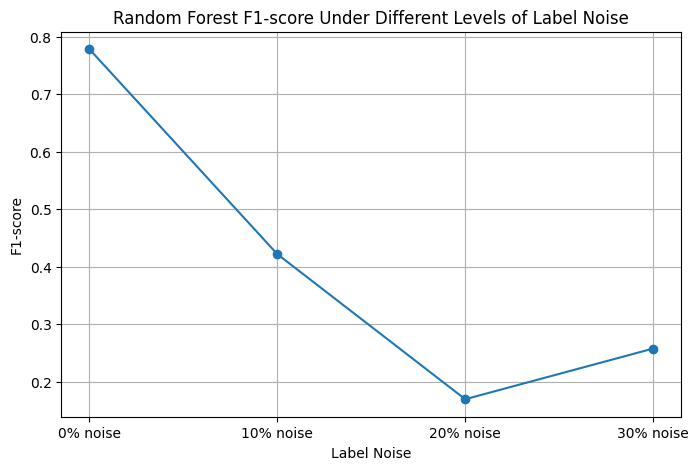

In [10]:
plt.figure(figsize=(8, 5))

plt.plot( comparison.index,comparison["F1-score"], marker="o")

plt.xlabel("Label Noise")
plt.ylabel("F1-score")
plt.title("Random Forest F1-score Under Different Levels of Label Noise")

plt.grid(True)

plt.savefig("random_forest_label_noise_f1.png")

plt.show()

## Analysis of Results

The results demonstrate that Random Forest performance is strongly affected by increasing levels of label noise.

With 0% label noise, the model achieved its best performance, with an Accuracy of 0.821 and an F1-score of 0.778. This represents the baseline performance of the Random Forest classifier on the clean dataset.

When 10% label noise was introduced, Accuracy decreased substantially to 0.480, while the F1-score decreased to 0.422. Precision also decreased from 0.800 to 0.486, and Recall decreased from 0.757 to 0.374.

At 20% label noise, the model experienced an even larger performance degradation. Accuracy dropped to 0.184 and the F1-score decreased to 0.170. Precision and Recall also fell to 0.214 and 0.142 respectively.

At 30% label noise, the model showed a small recovery compared with the 20% noise condition. Accuracy increased to 0.263 and the F1-score increased to 0.258. However, performance remained substantially lower than the baseline results.

The results indicate that Random Forest is highly sensitive to incorrect target labels. Even a moderate amount of label noise caused a large reduction in classification performance.

Overall, the experiment demonstrates that increasing label noise makes it more difficult for the Random Forest model to learn reliable relationships between the input features and the target variable.

## Conclusion

In this experiment, the effect of label noise on Random Forest performance was investigated using the Titanic dataset.

The Random Forest model achieved its highest performance with clean data, reaching an Accuracy of 0.821 and an F1-score of 0.778.

Introducing 10% label noise caused a substantial decrease in performance, with Accuracy falling to 0.480 and F1-score falling to 0.422. At 20% noise, performance decreased even further, reaching an Accuracy of 0.184 and an F1-score of 0.170.

Although the model showed a small improvement at 30% noise, its performance remained significantly below the baseline.

These findings demonstrate that label quality is a critical factor in machine learning. Incorrect target labels can strongly affect the learning process and lead to a substantial decrease in predictive performance, even when using an ensemble model such as Random Forest.